# Testing a Deployed Model Locally

Before a model goes to a cloud server it should pass a suite of local tests. Catching bugs locally is free; catching them after a cloud deployment costs money, time, and user trust. This notebook builds a minimal Flask API around a trained model and tests it for correctness, edge cases, and latency.

**Learning objectives**
1. Build a Flask `/predict` endpoint with input validation.
2. Write a happy-path test that checks output format and values.
3. Write edge-case tests for bad inputs and verify the API returns the right error code.
4. Measure p50 and p95 latency over 100 requests using `time.perf_counter()`.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 4, lesson 07 "07. Model Evaluation" — that lesson asked whether the *model* is right; this one asks whether the *service* is right: the correct status code on malformed input, and p50/p95 latency measured over repeated requests.


## 📰 Booking.com put a price on 30% more latency

At KDD 2019, Booking.com published what it learned from roughly **150 customer-facing machine-learning models** in production. One experiment in that paper is the reason section 5 of this notebook exists. They deliberately injected *synthetic latency* into live traffic and measured the business effect: an increase of about **30% in latency cost roughly 0.5% in conversion rate** — which, at their volume, they describe as a relevant cost to the business. Note what that experiment implies. The model was unchanged. Its accuracy was unchanged. Only the response time moved, and the money moved with it.

**What goes wrong without this lesson.** A model that is correct but slow, or correct but crashes on an empty request body, looks perfect in a training notebook and fails the moment a real client touches it. Teams discover both classes of bug the expensive way: after paying for cloud infrastructure, and after users have already had the bad experience. Every check below — happy path, malformed input, latency percentiles — is a bug you can find on your laptop in seconds instead of in production in hours.

## 1  Why test locally?

A cloud VM costs money the moment it starts. If your model crashes on an empty input, returns predictions in the wrong format, or takes 10 seconds per request, you want to know that before paying for cloud infrastructure. Local testing also gives a fast feedback loop: edit code, rerun, fix — no deploy cycle required.


In [1]:
# WHAT: make sure flask, scikit-learn and joblib are installed in this kernel.
# WHY: the whole lesson tests a local Flask app — a missing dependency should fail
# here at the top, not halfway through the tests. check=False keeps re-runs quiet.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "flask", "scikit-learn", "joblib"],
               check=False)
print("Dependencies ready")

Dependencies ready



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## 2  Train a model and build a Flask app

We train a RandomForest on Iris data, write it to disk, then define a Flask app with a `/predict` endpoint that validates input before calling the model.


In [2]:
# WHAT: train a small iris model and save it where the Flask app expects it.
# WHY: deployment testing needs a real artifact on disk — this stands in for the
# output of your training pipeline.
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib
import numpy as np

# Standard train/test split so the printed accuracy is an honest holdout number.
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

# Save to the exact path the Flask app below hard-codes — path mismatches are a
# classic local-deployment bug.
MODEL_PATH = "/tmp/test_iris_rf.joblib"
joblib.dump(clf, MODEL_PATH)
print(f"Model saved: test accuracy = {clf.score(X_test, y_test):.2%}")

Model saved: test accuracy = 100.00%


In [3]:
%%writefile /tmp/flask_app.py
# WHAT: write the Flask prediction app (with input validation) to /tmp/flask_app.py.
# WHY: this is the system under test — note how each validation step returns a
# specific HTTP status (400 vs 422) so clients can tell WHAT was wrong.
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)
MODEL_PATH = "/tmp/test_iris_rf.joblib"
CLASS_NAMES = ["setosa", "versicolor", "virginica"]
clf = joblib.load(MODEL_PATH)

REQUIRED_KEYS = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

@app.route("/health")
def health():
    return jsonify({"status": "ok"})

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json(silent=True)

    # Validate: must be a JSON object
    if data is None or not isinstance(data, dict):
        return jsonify({"error": "Request body must be a JSON object"}), 400

    # Validate: all required keys present
    missing = [k for k in REQUIRED_KEYS if k not in data]
    if missing:
        return jsonify({"error": f"Missing fields: {missing}"}), 422

    # Validate: all values must be numeric
    try:
        features = [float(data[k]) for k in REQUIRED_KEYS]
    except (ValueError, TypeError):
        return jsonify({"error": "All feature values must be numeric"}), 422

    # Validate: no out-of-range values (iris features in cm, 0-15 is reasonable)
    if any(v < 0 or v > 15 for v in features):
        return jsonify({"error": "Feature values out of expected range [0, 15]"}), 422

    arr = np.array([features])
    proba = clf.predict_proba(arr)[0]
    class_idx = int(np.argmax(proba))
    return jsonify({
        "prediction": CLASS_NAMES[class_idx],
        "confidence": round(float(proba[class_idx]), 4)
    })

if __name__ == "__main__":
    app.run(port=5000, debug=False)

Overwriting /tmp/flask_app.py


## 3  Test 1 — Happy path

Flask's `test_client()` lets us call the app in-process without starting a real server. We send a valid Iris sample and check that the response has the expected shape.


In [4]:
# WHAT: send one well-formed request through Flask's built-in test client.
# WHY: the happy path comes first — if a valid request fails, no other test matters.
# test_client() calls the app in-process, so no server or port is needed.
import sys, json
sys.path.insert(0, "/tmp")

# Reload in case the app file changed since the last notebook run.
import importlib
import flask_app as fa
importlib.reload(fa)

client = fa.app.test_client()

# Known setosa sample
payload = {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}
resp = client.post("/predict", data=json.dumps(payload), content_type="application/json")
body = json.loads(resp.data)

print(f"Status code : {resp.status_code}")
print(f"Prediction  : {body['prediction']}")
print(f"Confidence  : {body['confidence']}")

# Asserts turn this cell into a real test: any broken guarantee stops the notebook.
assert resp.status_code == 200, f"Expected 200, got {resp.status_code}"
assert "prediction" in body
assert "confidence" in body
assert body["prediction"] in ["setosa", "versicolor", "virginica"]
assert 0.0 <= body["confidence"] <= 1.0
print("Happy-path test PASSED")

Status code : 200
Prediction  : setosa
Confidence  : 1.0
Happy-path test PASSED


## 4  Test 2 — Edge cases

Edge cases are inputs that a real user might accidentally (or intentionally) send. A well-built API must reject them with a 4xx status code, never a 500 crash.


In [5]:
# Case A: empty body
resp_a = client.post("/predict", data="", content_type="application/json")
print(f"Empty body      -> status {resp_a.status_code}: {json.loads(resp_a.data)}")
assert resp_a.status_code == 400

# Case B: missing required field
partial = {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4}
resp_b = client.post("/predict", data=json.dumps(partial), content_type="application/json")
print(f"Missing field   -> status {resp_b.status_code}: {json.loads(resp_b.data)}")
assert resp_b.status_code == 422

# Case C: string value instead of float
bad_type = {"sepal_length": "five", "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}
resp_c = client.post("/predict", data=json.dumps(bad_type), content_type="application/json")
print(f"String value    -> status {resp_c.status_code}: {json.loads(resp_c.data)}")
assert resp_c.status_code == 422

# Case D: out-of-range value
oor = {"sepal_length": 999, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}
resp_d = client.post("/predict", data=json.dumps(oor), content_type="application/json")
print(f"Out-of-range    -> status {resp_d.status_code}: {json.loads(resp_d.data)}")
assert resp_d.status_code == 422

print("\nAll edge-case tests PASSED")


Empty body      -> status 400: {'error': 'Request body must be a JSON object'}
Missing field   -> status 422: {'error': "Missing fields: ['petal_width']"}
String value    -> status 422: {'error': 'All feature values must be numeric'}
Out-of-range    -> status 422: {'error': 'Feature values out of expected range [0, 15]'}

All edge-case tests PASSED


### 4.1  The same four requests, against an app that skips validation

Four status codes printed above, all correct. But "correct" only means something against an alternative, and the alternative is the app almost everyone writes first: read the JSON, index the four keys, call `predict`. Twelve lines instead of thirty, and it passes the happy-path test in section 3 exactly as well.

Write that app too and send both of them the same five requests, so the difference stops being a claim about good practice and becomes a table of what the client actually receives.

In [6]:
%%writefile /tmp/flask_app_novalidation.py
# WHAT: the same model behind the endpoint everyone writes first - no validation.
# WHY: this is the control condition. It is not a strawman: it loads the same
# artifact, returns the same JSON shape, and passes the section 3 happy-path test.
# The only thing missing is every check between get_json() and predict_proba().
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)
clf = joblib.load("/tmp/test_iris_rf.joblib")     # same artifact as the validated app
CLASS_NAMES = ["setosa", "versicolor", "virginica"]
REQUIRED_KEYS = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json(silent=True)
    features = [data[k] for k in REQUIRED_KEYS]   # no presence check, no type check
    proba = clf.predict_proba(np.array([features]))[0]
    class_idx = int(np.argmax(proba))
    return jsonify({"prediction": CLASS_NAMES[class_idx],
                    "confidence": round(float(proba[class_idx]), 4)})

Overwriting /tmp/flask_app_novalidation.py


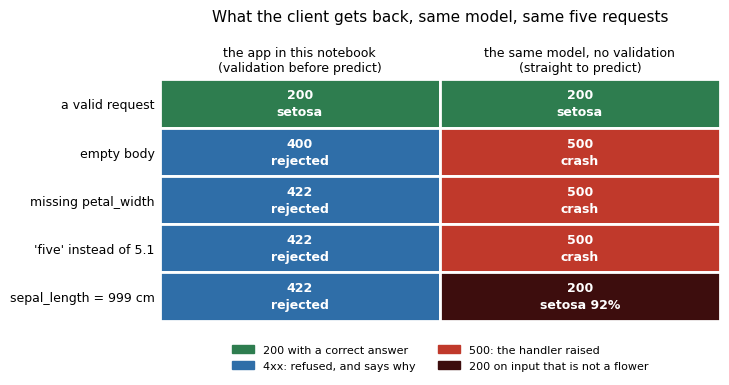

request                  validated app          unvalidated app
a valid request          200 setosa             200 setosa
empty body               400 rejected           500 crash
missing petal_width      422 rejected           500 crash
'five' instead of 5.1    422 rejected           500 crash
sepal_length = 999 cm    422 rejected           200 setosa 92%


In [7]:
# WHAT: send five identical requests to both apps and tabulate what comes back.
# WHY: an error code is a promise to the caller. This figure is the two promises
# side by side, for the same model and the same inputs.
import logging

from matplotlib.patches import Patch
import matplotlib.pyplot as plt

import flask_app_novalidation as naive
importlib.reload(naive)

# Both apps log a full traceback on a 500. We are deliberately causing those, so
# silence the loggers - the status code is the evidence we want, not the stack.
for _app in (fa.app, naive.app):
    _app.logger.disabled = True
logging.getLogger("werkzeug").setLevel(logging.CRITICAL)

naive_client = naive.app.test_client()

CASES = [
    ("a valid request",       {"sepal_length": 5.1, "sepal_width": 3.5,
                               "petal_length": 1.4, "petal_width": 0.2}),
    ("empty body",            None),
    ("missing petal_width",   {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4}),
    ("'five' instead of 5.1", {"sepal_length": "five", "sepal_width": 3.5,
                               "petal_length": 1.4, "petal_width": 0.2}),
    ("sepal_length = 999 cm", {"sepal_length": 999, "sepal_width": 3.5,
                               "petal_length": 1.4, "petal_width": 0.2}),
]

def send(a_client, payload):
    raw = "" if payload is None else json.dumps(payload)
    r = a_client.post("/predict", data=raw, content_type="application/json")
    try:
        return r.status_code, json.loads(r.data)
    except Exception:
        return r.status_code, {}                  # a 500 returns an HTML page, not JSON

def verdict(case_name, code, body):
    """Four outcomes, worst last: answered, refused, crashed, answered nonsense."""
    if code == 200 and case_name == "a valid request":
        return "ok", f"200\n{body.get('prediction', '')}"
    if code == 200:
        return "silent", f"200\n{body.get('prediction', '')} {body.get('confidence', 0):.0%}"
    if 400 <= code < 500:
        return "rejected", f"{code}\nrejected"
    return "crash", f"{code}\ncrash"

COLOR = {"ok": "#2e7d4f", "rejected": "#2f6ea8", "crash": "#c0392b", "silent": "#3d0d0d"}
row_labels, grid = [], []
for case_name, payload in CASES:
    row_labels.append(case_name)
    grid.append([verdict(case_name, *send(c, payload)) for c in (client, naive_client)])

n = len(row_labels)
fig, ax = plt.subplots(figsize=(7.4, 4.0))
for i, cells in enumerate(grid):
    for j, (kind, label) in enumerate(cells):
        ax.add_patch(plt.Rectangle((j, n - 1 - i), 1, 1,
                                   facecolor=COLOR[kind], edgecolor="white", lw=2))
        ax.text(j + 0.5, n - 0.5 - i, label, ha="center", va="center",
                color="white", fontsize=9, fontweight="bold", linespacing=1.4)
ax.set_xlim(0, 2); ax.set_ylim(0, n)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["the app in this notebook\n(validation before predict)",
                    "the same model, no validation\n(straight to predict)"], fontsize=9)
ax.set_yticks([n - 0.5 - i for i in range(n)])
ax.set_yticklabels(row_labels, fontsize=9)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.set_title("What the client gets back, same model, same five requests",
             fontsize=11, pad=42)
ax.legend(handles=[Patch(color=COLOR["ok"], label="200 with a correct answer"),
                   Patch(color=COLOR["rejected"], label="4xx: refused, and says why"),
                   Patch(color=COLOR["crash"], label="500: the handler raised"),
                   Patch(color=COLOR["silent"], label="200 on input that is not a flower")],
          loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

print(f"{'request':24s} {'validated app':22s} unvalidated app")
for case_name, cells in zip(row_labels, grid):
    left = cells[0][1].replace("\n", " ")
    right = cells[1][1].replace("\n", " ")
    print(f"{case_name:24s} {left:22s} {right}")

**Read the figure.** Two columns, five rows, one model. The top row is green on both sides: a valid request works in either app, which is exactly why the missing validation survives code review.

Every row below it disagrees.

- **Three red cells: `500`.** Empty body, missing field, `"five"` where a number belongs — the unvalidated handler raises `TypeError`, `KeyError` and sklearn's `ValueError` respectively, and Flask turns each into an Internal Server Error. A `500` tells the caller "the fault is mine", so an on-call engineer gets paged for a client that sent bad JSON. The blue cells on the left are the same three requests answered `400` / `422`: *your* request is wrong, here is which field.
- **The bottom-right cell is the dangerous one, and it is not red for a crash — it is `200`.** A sepal 999 cm long is not a flower, it is a unit error or a corrupted feed. The unvalidated service returns `setosa` with 92% confidence and no indication that anything is wrong. Nothing downstream can tell this apart from a real prediction. A crash gets fixed on the day it happens; this gets discovered a quarter later, in a report someone already acted on.

That bottom-right cell is the whole argument for the eighteen extra lines. And note which column the Cloudflare and Booking.com stories at the top of these notebooks belong to: not the crashing one.

## 5  Test 3 — Latency

We send 100 requests, measure each with `time.perf_counter()`, and compute p50 and p95. The p95 percentile is more useful than the mean because it tells you the worst-case experience for the slowest 5% of requests — the ones that actually cause users to notice lag.


In [8]:
# WHAT: fire 100 identical requests and summarize latency percentiles.
# WHY: services are judged by p95/p99, not the average — one slow request in twenty
# is what users actually feel, and what SLOs are written against.
import time
import numpy as np

payload_str = json.dumps({"sepal_length": 5.1, "sepal_width": 3.5,
                           "petal_length": 1.4, "petal_width": 0.2})
latencies_ms = []

# Time each request individually so we can build a latency distribution.
for _ in range(100):
    t0 = time.perf_counter()
    client.post("/predict", data=payload_str, content_type="application/json")
    latencies_ms.append((time.perf_counter() - t0) * 1000)

# Percentiles summarize the distribution: p50 = typical, p95/p99 = worst cases.
arr = np.array(latencies_ms)
print(f"100 requests completed")
print(f"  p50 (median)  : {np.percentile(arr, 50):.2f} ms")
print(f"  p95           : {np.percentile(arr, 95):.2f} ms")
print(f"  p99           : {np.percentile(arr, 99):.2f} ms")
print(f"  mean          : {arr.mean():.2f} ms")
print("\nNote: these are in-process numbers. Real HTTP adds ~1-5 ms network overhead.")

100 requests completed
  p50 (median)  : 1.23 ms
  p95           : 1.47 ms
  p99           : 1.66 ms
  mean          : 1.26 ms

Note: these are in-process numbers. Real HTTP adds ~1-5 ms network overhead.


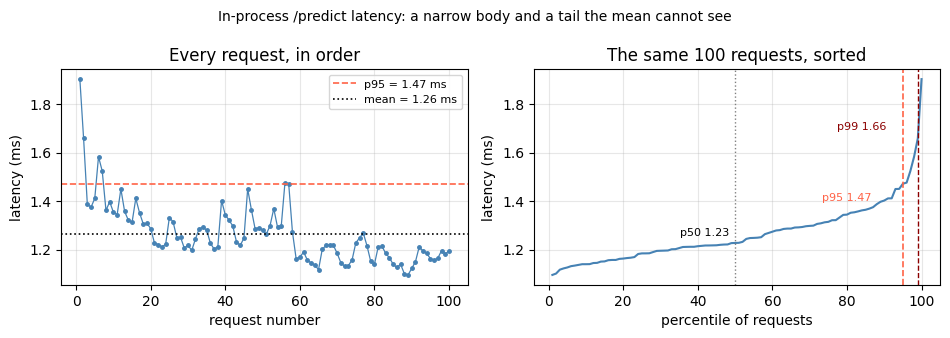

Slowest request      : #1 at 1.90 ms (1.6x the median)
p99 / p50            : 1.35x
Requests above the mean: 42 of 100


In [9]:
# WHAT: draw the 100 latencies we just measured - first in request order, then
# sorted, with the percentile lines marked on both.
# WHY: the four printed numbers are a summary of a shape. Seeing the shape is how
# you learn what a percentile actually reports, and why an SLO is never written
# against the mean.
import matplotlib.pyplot as plt

p50, p95, p99 = np.percentile(arr, [50, 95, 99])
mean_ms = arr.mean()

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))

# Left: every request, in the order it was sent.
ax = axes[0]
ax.plot(np.arange(1, len(arr) + 1), arr, color="steelblue", lw=0.9, marker="o", ms=2.5)
ax.axhline(p95, color="tomato", ls="--", lw=1.2, label=f"p95 = {p95:.2f} ms")
ax.axhline(mean_ms, color="black", ls=":", lw=1.2, label=f"mean = {mean_ms:.2f} ms")
ax.set_xlabel("request number")
ax.set_ylabel("latency (ms)")
ax.set_title("Every request, in order")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: the same numbers sorted - the x axis is now "percentile of requests".
ax = axes[1]
ax.plot(np.arange(1, len(arr) + 1) * 100 / len(arr), np.sort(arr), color="steelblue")
ax.axvline(50, color="grey", ls=":", lw=1)
ax.axvline(95, color="tomato", ls="--", lw=1.2)
ax.axvline(99, color="darkred", ls="--", lw=1)
ax.annotate(f"p50 {p50:.2f}", (50, p50), textcoords="offset points", xytext=(-40, 5), fontsize=8)
ax.annotate(f"p95 {p95:.2f}", (95, p95), textcoords="offset points", xytext=(-58, -12),
            fontsize=8, color="tomato")
ax.annotate(f"p99 {p99:.2f}", (99, p99), textcoords="offset points", xytext=(-58, 6),
            fontsize=8, color="darkred")
ax.set_xlabel("percentile of requests")
ax.set_ylabel("latency (ms)")
ax.set_title("The same 100 requests, sorted")
ax.grid(alpha=0.3)

fig.suptitle("In-process /predict latency: a narrow body and a tail the mean cannot see", fontsize=10)
plt.tight_layout()
plt.show()

slowest = int(np.argmax(arr)) + 1
print(f"Slowest request      : #{slowest} at {arr.max():.2f} ms "
      f"({arr.max() / p50:.1f}x the median)")
print(f"p99 / p50            : {p99 / p50:.2f}x")
print(f"Requests above the mean: {int((arr > mean_ms).sum())} of {len(arr)}")

**Read the figure.** The left panel is the 100 requests in the order they were sent — not a flat line but a spread, because identical work does not cost identical time on a real machine. The right panel is the same 100 numbers sorted, so the x axis becomes "percentile of requests": the curve moves through a narrow band across the body of the distribution and then turns sharply upward over the last few percent. That upturn is the tail, and p95/p99 are the only numbers in the printout that report it. The mean (dotted line, left panel) sits down inside the body — the printout says how many of the 100 requests were slower than it.

That is why a service level objective is written as "p95 under X ms" and never "average under X ms". The average is held down by the many fast requests; users complain about the few slow ones.

Check which request the printout names as the slowest. If it is `#1`, you are looking at first-call cost — imports, caches and lazy allocations that a freshly started process pays once. Every restart, every new pod and every scale-up pays it again, which is why a serving container is normally given warm-up requests before a load balancer is allowed to route real traffic to it.

Note the y-axis units. These are millisecond numbers because the request never leaves the process: `test_client()` skips sockets, TLS and the network entirely. The *shape* is real; the absolute values are a floor, not a prediction.

## 6  Combined pass/fail report


In [10]:
# WHAT: collect every check from this lesson into one pass/fail scorecard.
# WHY: this mirrors a CI gate — deployment is approved only if ALL functional and
# latency checks pass, not just the ones we remembered to look at.
# Re-run the happy path to get a fresh response
resp = client.post("/predict", data=payload_str, content_type="application/json")
body = json.loads(resp.data)

# Each entry is a named boolean: earlier cells produced the responses we grade here.
checks = {
    "happy_path_status_200"    : resp.status_code == 200,
    "has_prediction_key"       : "prediction" in body,
    "has_confidence_key"       : "confidence" in body,
    "confidence_in_0_1"        : 0.0 <= body.get("confidence", -1) <= 1.0,
    "empty_body_returns_400"   : resp_a.status_code == 400,
    "missing_field_returns_422": resp_b.status_code == 422,
    "wrong_type_returns_422"   : resp_c.status_code == 422,
    "out_of_range_returns_422" : resp_d.status_code == 422,
    "p95_under_500ms"          : float(np.percentile(arr, 95)) < 500,
}

# Print a PASS/FAIL line per check so a failure is easy to locate.
for name, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")

print(f"\n{'ALL TESTS PASSED' if all(checks.values()) else 'SOME TESTS FAILED'}")

  [PASS] happy_path_status_200
  [PASS] has_prediction_key
  [PASS] has_confidence_key
  [PASS] confidence_in_0_1
  [PASS] empty_body_returns_400
  [PASS] missing_field_returns_422
  [PASS] wrong_type_returns_422
  [PASS] out_of_range_returns_422
  [PASS] p95_under_500ms

ALL TESTS PASSED


## 💬 Discuss

Our nine checks all passed and the printed p95 came in at **a millisecond and a bit** against a 500 ms budget — a margin of a few hundred times over. Now argue about what that scorecard is worth.

1. Booking.com found that a 30% latency increase was commercially meaningful. Read your own p95 off the printout; a 30% increase on it is a fraction of a millisecond. Is a latency budget even the right gate for *this* service, or are we measuring something that cannot hurt us? What would have to be true about the model or the traffic for latency to become the binding constraint?
2. The out-of-range check rejects any feature outside `[0, 15]` cm. That is defensible for iris petals. Write down what you would do for a credit-risk model whose inputs are standardized (mean 0, sd 1) and can legitimately be negative — and then decide whether "reject out-of-range input" is a rule for all ML APIs or only for some.
3. All nine checks are green, and the service will still fail in production for reasons this notebook cannot see. Name two, and say for each whether you would catch it with a *better test* or only with *monitoring*.

## Summary

Testing a deployed model locally means running three categories of checks before touching a cloud environment:

| Test category | What it catches |
|---|---|
| Happy path | Basic correctness — model returns valid, properly shaped predictions |
| Edge cases | Bad inputs that should return 4xx, not crash with 500 |
| Latency | Whether the model meets performance requirements (check p95, not mean) |

Flask's `test_client()` lets you run all of this without starting a real server.


## Self-check

1. **What latency would you expect from a simple sklearn RandomForest, and how would that compare to a 7B parameter LLM?** Look at the numbers measured in the latency cell, then consider how much more computation a 7B-parameter autoregressive model requires.
2. **What HTTP status code should a validation error return — 400, 422, or 500?** Check what the Flask app returns for a missing field vs an empty body, and explain the semantic difference.
3. **Name two things that could pass all local tests but still fail in production.** Hint: think about differences between your laptop and a cloud server — OS libraries, Python versions, concurrent users, memory limits.


## ⚠️ Where this breaks

The whole point of `test_client()` is that it is cheap. What you buy for that price is limited, and the limits are worth stating exactly.

- **These are not latency numbers.** `test_client()` calls the Flask app **in-process**: no TCP, no TLS handshake, no JSON going over a wire, no WSGI server, no other requests competing for CPU. The cell says so, and the number to hold onto is that real HTTP typically adds milliseconds on top of an in-process measurement of around one millisecond. Never quote an in-process p95 in a capacity plan.
- **One request at a time is the wrong shape of test.** Every failure that only appears under concurrency — a worker exhausting memory, a thread-unsafe global, a connection pool running dry — is invisible to a sequential loop of 100 calls. Load testing (`locust`, `k6`, `wrk`) is a different tool, and it belongs before a launch, not after.
- **The assumption that must hold:** your laptop resembles the target machine. It usually does not. Different CPU, different BLAS build, different OS libraries, different Python. This is exactly the gap Unit 4's Docker image closes, and the reason "it passed locally" is a weaker claim than it sounds.
- **A green scorecard is a floor, not a ceiling.** These tests assert the *service* behaves; none of them assert the *model* is any good. A model that returns `setosa` for every input passes all nine checks here. Notebook 05 adds the accuracy gate that catches it.
- **The cheaper alternative.** For a service that is only ever called by a scheduled internal job, skip the HTTP layer and its whole test suite: test the scoring function directly and run it as a batch script. Most of this notebook's machinery is the price of being reachable over a network — do not pay it if nothing reaches you over a network.

## 📚 References

1. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
2. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
3. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. <https://arxiv.org/abs/2011.09926>
4. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2024). *"We Have No Idea How Models will Behave in Production until Production": How Engineers Operationalize Machine Learning*. Proceedings of the ACM on Human-Computer Interaction, 8(CSCW1), Article 206. <https://arxiv.org/abs/2403.16795>
5. Rabanser, S., Kapoor, S., Kirgis, P., et al. (2026). *Towards a Science of AI Agent Reliability*. arXiv:2602.16666. <https://arxiv.org/abs/2602.16666>
